# Best Camera Model — HPO + Final Training + Evaluation

One self-contained experiment: find hyperparameters that make **end-to-end
vision** (camera → CNN → steering/throttle) actually learn, then train the
best configuration at scale with the full sim2real DR stack, evaluate it,
and export an ONNX bundle for the physical car.

**Why HPO is the core here:** before this run, every camera policy in this
repo ended at **0% lap completion** — including a full 10M-step
`CameraMadronaDr` run — while feature-vector policies complete 100% in the
same environment. The `camera_std_sweep` diagnostics established that
action-std dynamics are only stable with a `std_range=(0.1, 1.0)` ceiling;
this study keeps that fixed and searches the remaining first-order
suspects (lr, entropy, frame stack, discount, batch shape) with no DR and
a single track, so trials measure pure learning ability.

Everything runs in-process — cells build specs with the stage DSL and call
`run()` directly. Each named step records its result under
`runs/best_camera/logs/`; set `REUSE = True` to re-execute the notebook
against those records without retraining anything. The ONNX export is the
single subprocess (genesis and onnxruntime cannot share a process).


In [1]:
# --- experiment configuration (papermill parameters cell) ------------------
SEED = 0
ROOT = "runs/best_camera"
WALL_BUDGET_H = 10.0
REUSE = False                      # replay recorded step results

# renderer bench
BENCH_STEPS = 150
BENCH_CONFIGS = [("madrona", 64), ("madrona", 128), ("nyx", 64), ("nyx", 128)]
NYX_SLOWDOWN_OK = 2.0              # prefer nyx unless > this x slower

# HPO (no-DR, single track: measures pure learning ability)
HPO_TRIALS = 16
HPO_DEADLINE_H = 3.4
TRIAL_STEPS = 1_200_000
TRIAL_EVAL_EVERY = 600_000
TRIAL_TRACK = "reinvent_base"

# final training (winner config + zoo + full DR)
FINAL_STEPS_MAX = 30_000_000
FINAL_STEPS_MIN = 2_000_000
FINAL_RESERVE_H = 1.0
FINAL_EVALS = 6

RESOLUTION = (160, 120)            # physical-camera parity


In [2]:
# Parameters
REUSE = True


In [3]:
"""Session helpers: result caching, figure display, budget clock.

Everything runs **in this process** — genesis rebuilds scenes fine within
one process (the hpo example relies on it), and a dead training draw is
stopped by raising out of ``run(on_eval=...)`` rather than killing a child
process. Each named step's result is recorded as JSON under
``<ROOT>/logs``; with ``REUSE = True`` an existing result is returned
instead of recomputed, so a finished notebook re-executes in minutes
without retraining — and if a hard GPU fault ever kills the kernel (e.g.
VRAM exhausted by another process), restarting with ``REUSE = True``
resumes from the last recorded step instead of from scratch. The one exception is the ONNX export, which must run
in a genesis-free process (LLVM symbol clash) — it stays a single CLI
subprocess at the end.
"""

import io
import json
import os
import time

from IPython.display import Image, display

from deepracer_genesis.experiment import run

# survive a shared GPU: cap Madrona's device heap (its default does not fit
# next to a resident LLM server) and let torch grow segments on demand
os.environ.setdefault("MADRONA_MWGPU_DEVICE_HEAP_SIZE", str(1 << 30))
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

T0 = time.time()
LOGS = os.path.join(ROOT, "logs")
os.makedirs(LOGS, exist_ok=True)


def elapsed_h() -> float:
    """Wall-clock hours since the notebook started."""
    return (time.time() - T0) / 3600.0


def recorded(name: str):
    """Return a step's recorded result when REUSE is on and it exists."""
    path = os.path.join(LOGS, f"{name}.result.json")
    if REUSE and os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None


def record_result(name: str, result: dict) -> dict:
    """Write a step's result JSON and return it."""
    with open(os.path.join(LOGS, f"{name}.result.json"), "w") as f:
        json.dump(result, f)
    return result


def cached_run(name: str, spec, on_eval=None) -> dict:
    """Train ``spec`` (or return the step's recorded result).

    Args:
        name: Step name — keys the result JSON under ``LOGS``.
        spec: The built ExperimentSpec to train.
        on_eval: Optional periodic-eval callback; raising inside it stops
            the run (the takeoff guard and HPO pruning both use this).

    Returns:
        ``{"metrics", "history", "holdout", "train", "run_dir"}``.
    """
    result = recorded(name)
    if result is not None:
        return result
    rec = run(spec, root=ROOT, on_eval=on_eval)
    return record_result(name, {
        "metrics": rec.metrics, "history": rec.eval_history,
        "holdout": rec.holdout, "train": rec.train,
        "run_dir": spec.run_dir(ROOT)})


def show_fig(fig) -> None:
    """Render a figure inline regardless of the active matplotlib backend.

    ``analysis.trackplots`` forces Agg, under which plain ``plt.show()``
    renders nothing in a notebook.

    Args:
        fig: The matplotlib figure.
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(buf.getvalue()))

def bench(name: str, spec, steps: int = BENCH_STEPS) -> dict:
    """Measure a spec's rollout throughput (cached by step name).

    Rollout-only — PPO training runs several times slower; only the ratio
    between configs transfers.

    Args:
        name: Step name for the result cache.
        spec: The built spec to bench.
        steps: Timed control steps.

    Returns:
        ``{"env_steps_per_s": float}`` (or ``{"error": ...}``).
    """
    result = recorded(name)
    if result is not None:
        return result
    import torch

    from deepracer_genesis.experiment.builder import Builder
    from deepracer_genesis.experiment.evaluator import evaluate_policy

    try:
        sim = Builder(spec).sim()
        actor_action = torch.zeros(sim.num_envs, 2, device=sim.device)
        actor_action[:, 1] = 0.4

        def actor(td):
            td.set("action", actor_action)
            return td

        with torch.inference_mode():
            evaluate_policy(sim, actor, steps=30)          # warmup / JIT
            t0 = time.perf_counter()
            evaluate_policy(sim, actor, steps=steps)
            dt = time.perf_counter() - t0
        result = {"env_steps_per_s": round(steps * sim.num_envs / dt, 1)}
    except Exception as e:                    # noqa: BLE001 - table shows it
        result = {"error": f"{type(e).__name__}: {e}"}
    return record_result(name, result)


In [4]:
"""Spec building: one pipeline factory covers trials and the final run."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deepracer_genesis.experiment import (
    AsymmetricCameraPolicy, CameraEnvironment, DomainRandomizationActions,
    DomainRandomizationCamera, DomainRandomizationPhysics,
    DomainRandomizationTrackAppearance, Evaluation, PPO)


def camera_spec(*, render="madrona", num_envs=64, tracks=(TRIAL_TRACK,),
                frame_stack=4, dr=False, random_direction=False,
                real_tracks=(), lr=3e-4, entropy_coef=3e-3, epochs=5,
                minibatches=4, gamma=0.99, steps=TRIAL_STEPS,
                eval_every=TRIAL_EVAL_EVERY, variant="probe"):
    """Build one camera ExperimentSpec for this study.

    Args:
        render: Renderer ("madrona" / "nyx").
        num_envs: Parallel cars.
        tracks: Track names to train on.
        frame_stack: Frames stacked along channels.
        dr: Apply the full appearance/camera/physics/action DR stack.
        random_direction: Coin-flip driving direction per episode.
        real_tracks: Per-track no-DR holdout eval after training.
        lr: PPO learning rate.
        entropy_coef: PPO entropy bonus.
        epochs: PPO epochs per iteration.
        minibatches: PPO minibatches per epoch.
        gamma: Reward discount.
        steps: Total env-steps.
        eval_every: Periodic-eval cadence (0 = final eval only).
        variant: Run-dir variant name.

    Returns:
        The validated frozen spec.
    """
    pipe = CameraEnvironment(render=render, resolution=RESOLUTION,
                             num_envs=num_envs, tracks=tuple(tracks),
                             frame_stack=frame_stack,
                             random_direction=random_direction)
    if dr:
        pipe = (pipe
                >> DomainRandomizationTrackAppearance(strength=0.6)
                >> DomainRandomizationCamera(brightness=(0.7, 1.3), hue=0.05,
                                             blur=0.3, camera_jitter=True)
                >> DomainRandomizationPhysics())
    pipe = pipe >> AsymmetricCameraPolicy(
        actor_keys=("camera",), critic_keys=("camera", "state"),
        distribution={"std_range": (0.1, 1.0)})
    if dr:
        pipe = pipe >> DomainRandomizationActions(
            steer_noise=0.02, speed_noise=0.05, delay_steps=1)
    pipe = pipe >> PPO(lr=lr, entropy_coef=entropy_coef, epochs=epochs,
                       minibatches=minibatches, gamma=gamma)
    if real_tracks:
        pipe = pipe >> Evaluation(real_tracks=tuple(real_tracks), charts=True)
    return pipe.build(seed=SEED, total_env_steps=steps,
                      eval_every_steps=eval_every,
                      group="best_camera", variant=variant)


print(f"root={ROOT} seed={SEED} budget={WALL_BUDGET_H}h reuse={REUSE}")


root=runs/best_camera seed=0 budget=10.0h reuse=True


[I 08/29/26 13:33:11.317 291395] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


[Genesis] [13:33:15] [WARNING] Mesh is not watertight. Falling back to convex hull for estimating inertial properties.


[Genesis] [13:33:15] [WARNING] Mesh is not watertight. Falling back to convex hull for estimating inertial properties.


[Genesis] [13:33:15] [WARNING] Mesh is not watertight. Falling back to convex hull for estimating inertial properties.


[Genesis] [13:33:15] [WARNING] Mesh is not watertight. Falling back to convex hull for estimating inertial properties.


...

[Genesis] [13:33:17] [WARNING] This property is deprecated and will be removed in future release. Please use 'dofs_idx_local' instead.


[Genesis] [13:33:17] [WARNING] This property is deprecated and will be removed in future release. Please use 'dofs_idx_local' instead.


[Genesis] [13:33:17] [WARNING] This property is deprecated and will be removed in future release. Please use 'dofs_idx_local' instead.


[Genesis] [13:33:17] [WARNING] This property is deprecated and will be removed in future release. Please use 'dofs_idx_local' instead.


[Genesis] [13:33:17] [WARNING] This property is deprecated and will be removed in future release. Please use 'dofs_idx_local' instead.


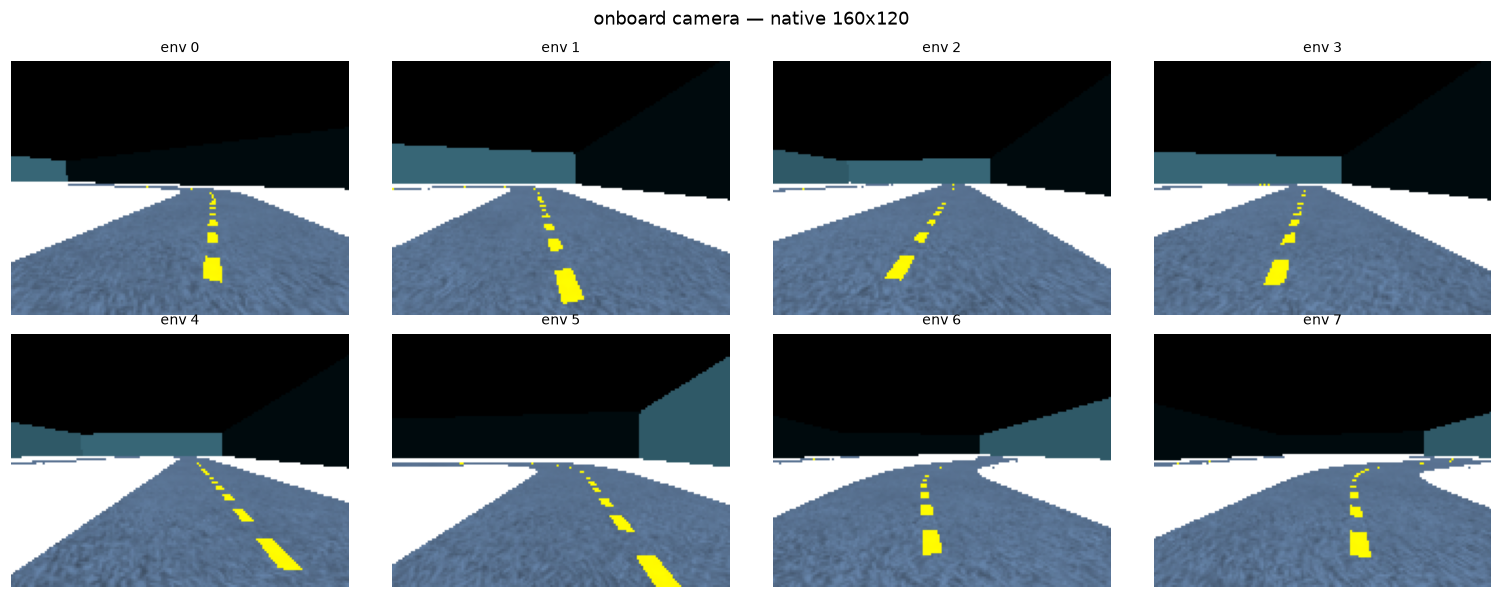

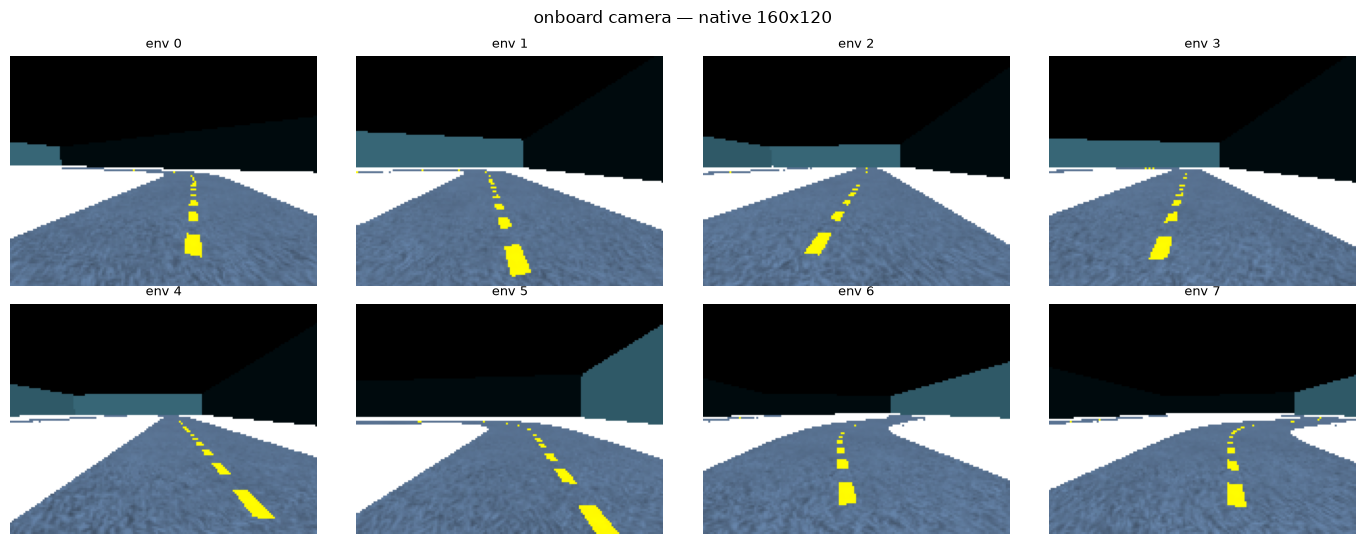

In [5]:
"""Sanity: what the car actually sees, before spending hours training on it."""

from deepracer_genesis.experiment import view_zoo

images = view_zoo(camera_spec(num_envs=8), num_envs=8)
fig, axes = plt.subplots(2, 4, figsize=(14, 5.5))
for i, (image, ax) in enumerate(zip(images, axes.flat)):
    ax.imshow(image); ax.set_title(f"env {i}", fontsize=9); ax.axis("off")
fig.suptitle("onboard camera — native 160x120")
fig.tight_layout()
show_fig(fig)


In [6]:
"""Renderer bench: measure Madrona vs Nyx, then decide with numbers."""

results = {}
for render, n in BENCH_CONFIGS:
    r = bench(f"bench_{render}_{n}", camera_spec(render=render, num_envs=n))
    results[(render, n)] = r.get("env_steps_per_s")
    print(f"{render:8s} x{n:4d}: {results[(render, n)]} env-steps/s"
          + (f"   ({r['error']})" if "error" in r else ""))


def pick_renderer(results: dict) -> tuple:
    """Choose (render, num_envs) from the measured throughput table.

    Nyx wins (better photorealism, better sim2real) unless it is more than
    ``NYX_SLOWDOWN_OK``x slower than the best Madrona config or broken.

    Args:
        results: ``{(render, num_envs): env_steps_per_s | None}``.

    Returns:
        The chosen ``(render, num_envs)`` pair.
    """
    best = {}
    for (render, n), sps in results.items():
        if sps and (render not in best or sps > best[render][0]):
            best[render] = (sps, n)
    assert best, "no renderer produced a benchmark result"
    if "nyx" in best and "madrona" in best:
        slowdown = best["madrona"][0] / best["nyx"][0]
        if slowdown <= NYX_SLOWDOWN_OK:
            return ("nyx", best["nyx"][1])
        print(f"nyx is {slowdown:.1f}x slower than madrona "
              f"(> {NYX_SLOWDOWN_OK}x budget rule) — using madrona")
        return ("madrona", best["madrona"][1])
    render = next(iter(best))
    return (render, best[render][1])


RENDER, NUM_ENVS = pick_renderer(results)
SPS_EST = results[(RENDER, NUM_ENVS)]
print(f"\ndecision: render={RENDER} num_envs={NUM_ENVS} "
      f"(~{SPS_EST:.0f} env-steps/s rollout)")


madrona  x  64: 9445.1 env-steps/s
madrona  x 128: 14637.7 env-steps/s
nyx      x  64: 1468.6 env-steps/s
nyx      x 128: 1544.0 env-steps/s
nyx is 9.5x slower than madrona (> 2.0x budget rule) — using madrona

decision: render=madrona num_envs=128 (~14638 env-steps/s rollout)


## HPO — make vision learn at all

Short no-DR trials on a single track isolate *learning ability*. The
metric is **`mean_progress_m`** at the trial's final deterministic eval —
completion is 0 for nearly all camera configs, while progress is a dense,
discriminative signal (the historical plateau to beat is ~1.9 m). Trials
run in-process, exactly like `examples/hpo.py`.


In [7]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial: optuna.Trial) -> float:
    """Train one short no-DR camera config and score its final eval.

    Args:
        trial: The Optuna trial supplying hyperparameters.

    Returns:
        ``mean_progress_m`` of the final deterministic eval.
    """
    spec = camera_spec(
        render=RENDER, num_envs=NUM_ENVS,
        lr=trial.suggest_float("lr", 3e-5, 6e-4, log=True),
        entropy_coef=trial.suggest_float("entropy_coef", 3e-4, 1e-2, log=True),
        epochs=trial.suggest_int("epochs", 3, 6),
        minibatches=trial.suggest_categorical("minibatches", [4, 8]),
        frame_stack=trial.suggest_categorical("frame_stack", [1, 4]),
        gamma=trial.suggest_categorical("gamma", [0.99, 0.995]),
        variant=f"t{trial.number:03d}")
    m = cached_run(f"trial_{trial.number:03d}", spec)["metrics"]
    print(f"  trial {trial.number}: progress={m['mean_progress_m']:.2f}m "
          f"completion={m['completion_rate']:.2f}")
    return float(m["mean_progress_m"])


study = optuna.create_study(
    direction="maximize", study_name="best_camera",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=f"sqlite:///{ROOT}/study.db", load_if_exists=True)
if not study.trials:                       # anchor: best-known config
    study.enqueue_trial({"lr": 3e-4, "entropy_coef": 3e-3, "epochs": 5,
                         "minibatches": 8, "frame_stack": 4, "gamma": 0.99})

while (sum(t.state.is_finished() for t in study.trials) < HPO_TRIALS
       and elapsed_h() < HPO_DEADLINE_H):
    study.optimize(objective, n_trials=1)

trials_df = pd.DataFrame([
    {"trial": t.number, "state": t.state.name, "progress_m": t.value,
     **t.params}
    for t in study.trials]).sort_values("progress_m", ascending=False)
display(trials_df.head(20))
BEST = dict(study.best_params)
print("winner:", BEST)


,trial,state,progress_m,lr,entropy_coef,epochs,minibatches,frame_stack,gamma
1,1,COMPLETE,12.735991,0.000155,0.003684,5,4,1,0.995
13,13,COMPLETE,1.852916,0.000035,0.009509,3,4,1,0.995
12,12,COMPLETE,1.824653,0.000032,0.009250,3,4,1,0.995
10,10,COMPLETE,1.792427,0.000056,0.000528,5,8,1,0.995
11,11,COMPLETE,1.739328,0.000045,0.000598,4,4,1,0.990
15,15,COMPLETE,1.703970,0.000096,0.009159,3,4,1,0.995
4,4,COMPLETE,1.641445,0.000155,0.003684,5,4,1,0.995
9,9,COMPLETE,1.626732,0.000224,0.000627,3,8,1,0.990
7,7,COMPLETE,1.566119,0.000508,0.001870,4,8,4,0.995
3,3,COMPLETE,1.512241,0.000300,0.003000,5,8,4,0.990


winner: {'lr': 0.00015529021289627495, 'entropy_coef': 0.00368356162276608, 'epochs': 5, 'minibatches': 4, 'frame_stack': 1, 'gamma': 0.995}


## Final training — winner config, track zoo, full DR

The winning hyperparameters train long with everything the physical car
needs: the demo zoo's 6 pre-baked reinvent variants split train/test with
`reinvent_base` held out of both, the full DR stack, and per-episode
direction randomization. The step budget is sized from measured throughput
against the wall-clock hours left.


In [8]:
from deepracer_genesis.datasets.splits import TrackDataset
from deepracer_genesis.tools.zoo import compile_zoo, demo_zoo

zoo_names = compile_zoo(demo_zoo())
split = TrackDataset(names=zoo_names, holdout=("reinvent_base",),
                     test_fraction=0.2, seed=SEED)
print(f"train={split.train}\ntest={split.test}\nholdout={split.holdout}")

r = bench("bench_final", camera_spec(
    render=RENDER, num_envs=NUM_ENVS, tracks=split.train, dr=True,
    random_direction=True, variant="final", **BEST))
sps_final = r.get("env_steps_per_s") or SPS_EST * 0.7
print(f"final-spec rollout throughput: {sps_final:.0f} env-steps/s")

train_h = max(0.0, WALL_BUDGET_H - elapsed_h() - FINAL_RESERVE_H)
FINAL_STEPS = int(min(FINAL_STEPS_MAX,
                      max(FINAL_STEPS_MIN, train_h * 3600 * sps_final * 0.9)))
EVAL_EVERY = max(FINAL_STEPS // FINAL_EVALS, 500_000)
print(f"budget left {train_h:.2f}h -> FINAL_STEPS={FINAL_STEPS:,}")

final = cached_run("final", camera_spec(
    render=RENDER, num_envs=NUM_ENVS, tracks=split.train, dr=True,
    random_direction=True,
    real_tracks=tuple(split.test) + tuple(split.holdout),
    steps=FINAL_STEPS, eval_every=EVAL_EVERY, variant="final", **BEST))
RUN_DIR = final["run_dir"]
print(f"run: {RUN_DIR}")
print("train:", final["train"])
print("metrics:", {k: round(v, 3) for k, v in final["metrics"].items()
                   if isinstance(v, (int, float))})


train=('reinvent_base_asphalt_light_fsand_bwhite', 'reinvent_base_dusk_bdark', 'reinvent_base_w090_bwhite', 'reinvent_base_w115')
test=('reinvent_base_w115_faded_fconcrete',)
holdout=('reinvent_base',)
final-spec rollout throughput: 8372 env-steps/s
budget left 9.00h -> FINAL_STEPS=30,000,000
run: runs/best_camera/best_camera/final-0-fc7ff6377a6c
train: {'wall_clock_s': 10307.9, 'total_env_steps': 29998080, 'steps_per_s': 2910.2, 'checkpoint': 'runs/best_camera/best_camera/final-0-fc7ff6377a6c/model.pt', 'backend': 'rsl_rl'}
metrics: {'episodes': 422, 'mean_return': 152.878, 'mean_progress_m': 15.21, 'mean_episode_s': 8.315, 'completion_rate': 0.263, 'mean_laps': 0.859, 'offtrack_rate': 0.922, 'lap_time_s': 9.318, 'mean_speed_mps': 1.712}


<deepracer-genesis>/deepracer_genesis/experiment/spec.py:437: UserWarning: multi-track camera training uses Part O spatial tiling: all 4 track meshes load into every env (render + memory scale ~K); benchmark aggregate steps/sec before scaling the track count
  self._validate_obs_dr()


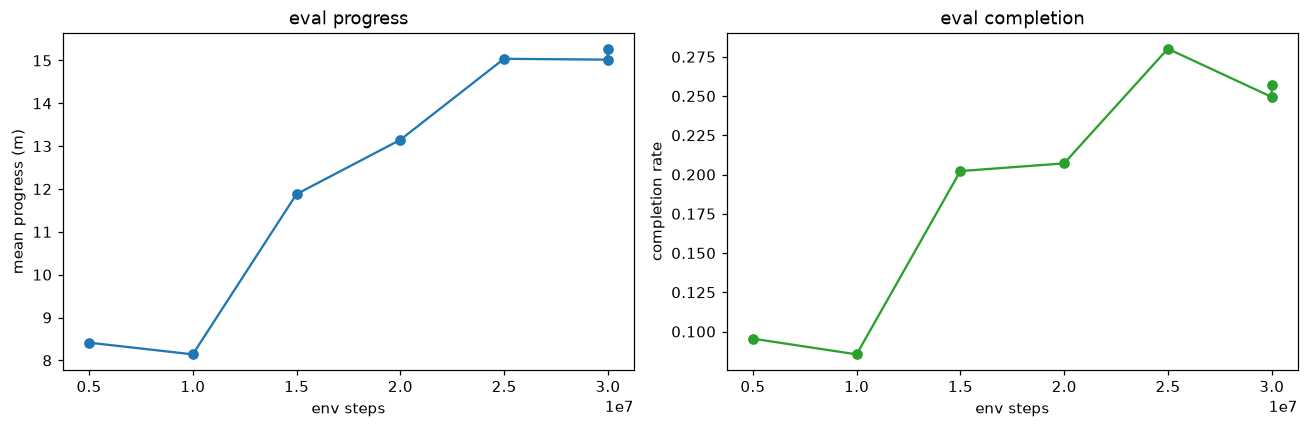

,mean_progress_m,completion_rate,offtrack_rate,mean_speed_mps
reinvent_base_w115_faded_fconcrete,27.834,0.589,0.759,1.716
reinvent_base,18.287,0.353,0.940,1.647


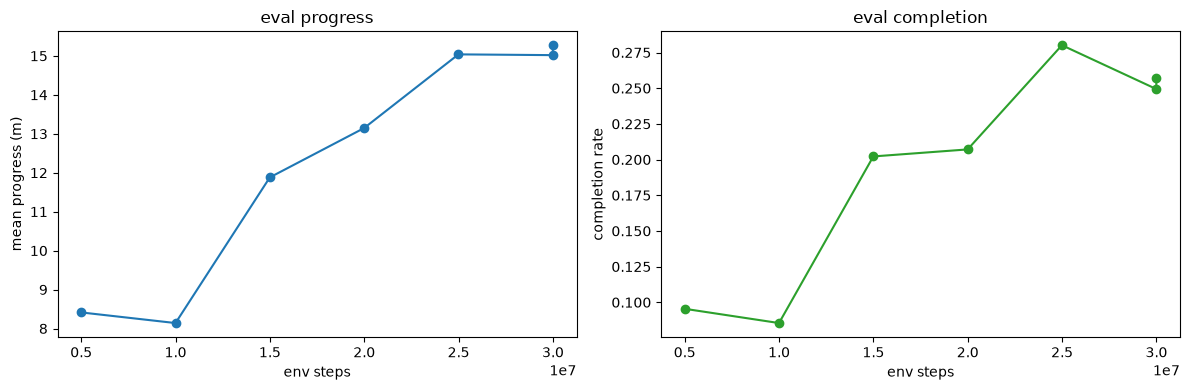

In [9]:
"""Evaluation: learning curve and the holdout table."""

hist = pd.DataFrame(final["history"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["frames"], hist["mean_progress_m"], marker="o")
ax[0].set(xlabel="env steps", ylabel="mean progress (m)", title="eval progress")
ax[1].plot(hist["frames"], hist["completion_rate"], marker="o", color="tab:green")
ax[1].set(xlabel="env steps", ylabel="completion rate", title="eval completion")
fig.tight_layout()
show_fig(fig)

if final.get("holdout"):
    display(pd.DataFrame(final["holdout"]).T[
        ["mean_progress_m", "completion_rate", "offtrack_rate",
         "mean_speed_mps"]].round(3))


,track,env,episode,steps,time_s,progress_total_m,completion,mean_speed,max_speed,total_reward,off_track_steps,completed_lap
518,reinvent_base_w115,118,0,1500,29.999999,71.717148,4.049721,2.286620,2.997462,756.075684,0,True
486,reinvent_base_w115,107,0,1500,29.999999,71.135849,4.016896,2.328897,3.059864,750.748718,0,True
458,reinvent_base_w115,98,0,1491,29.819999,68.879936,3.889509,2.288845,3.255414,716.954834,1,True
455,reinvent_base_w115,97,0,1500,29.999999,62.244583,3.514824,1.882324,2.991515,662.358459,0,True
165,reinvent_base_dusk_bdark,38,1,1500,29.999999,61.047203,3.447211,1.936892,3.063784,648.424988,0,True
146,reinvent_base_dusk_bdark,33,1,1500,29.999999,61.015038,3.445394,1.998015,3.226572,647.390442,0,True
473,reinvent_base_w115,103,1,1500,29.999999,60.276535,3.403693,1.922727,3.038456,635.236267,0,True
537,reinvent_base_w115,123,0,1434,28.679999,59.370846,3.352550,1.904185,2.951849,619.184326,1,True
411,reinvent_base_w090_bwhite,88,0,1500,29.999999,59.232178,3.344720,1.956973,3.209641,633.503601,0,True
492,reinvent_base_w115,109,0,1360,27.199999,58.872864,3.324430,2.200468,3.227063,612.589722,1,True


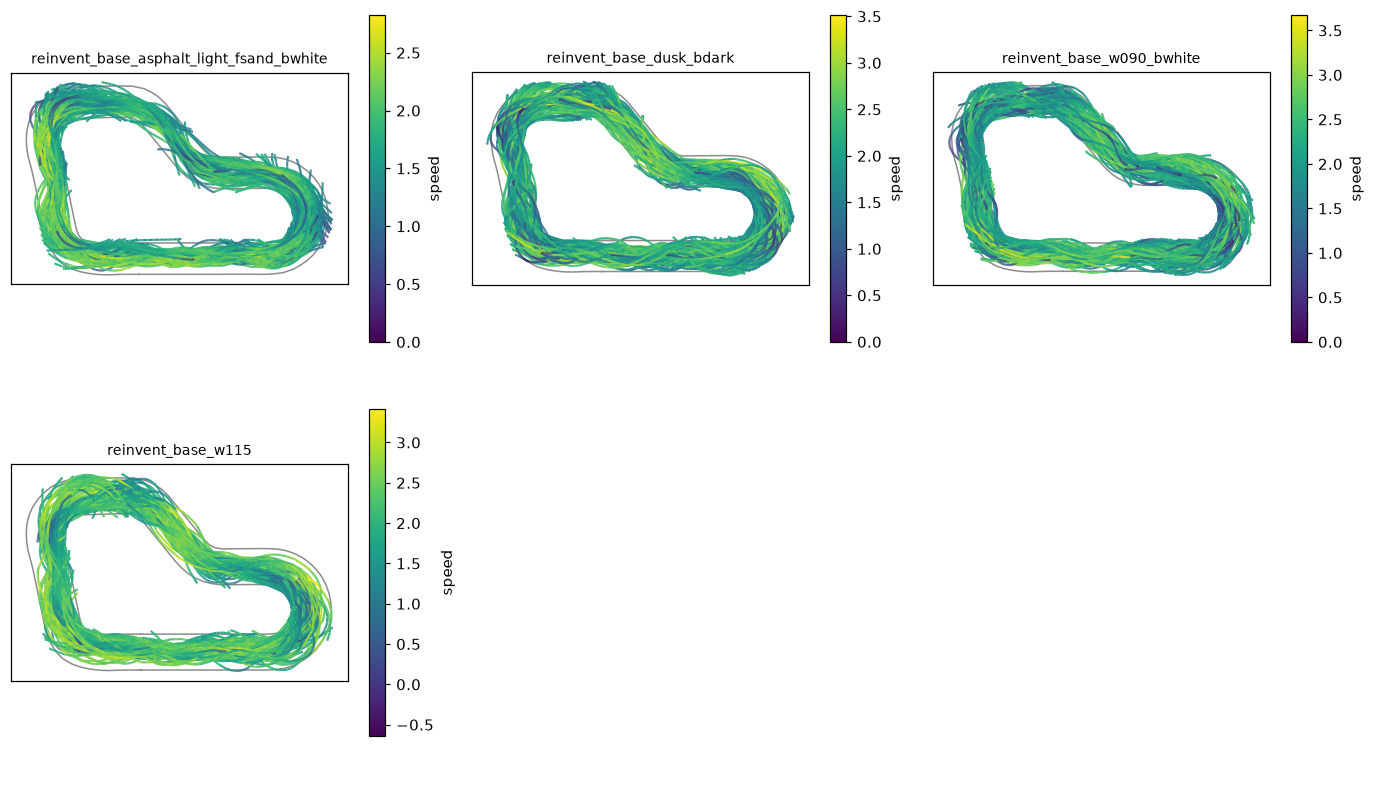

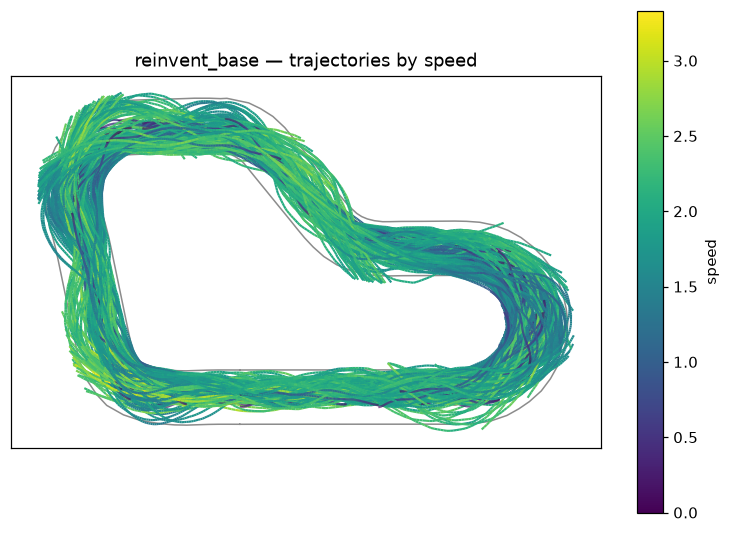

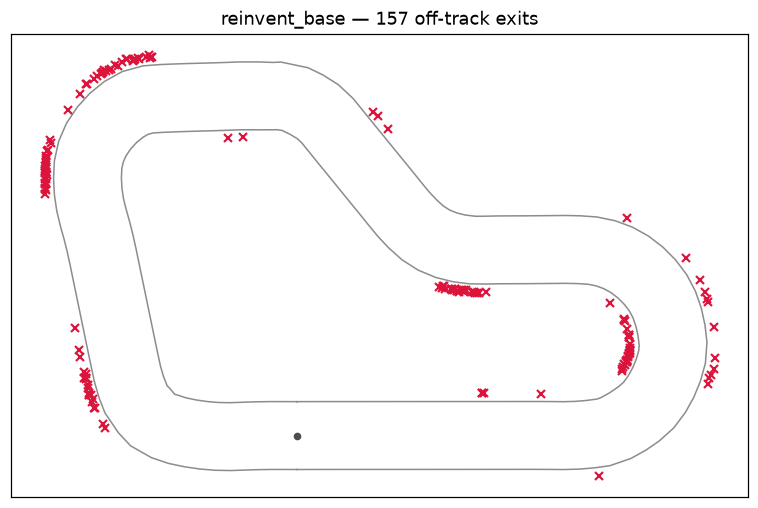

In [10]:
"""Trajectories from the recorded telemetry (final + holdout evals)."""

import os

from deepracer_genesis.analysis.telemetry import episode_agg, load_telemetry
from deepracer_genesis.analysis.trackplots import (plot_offtrack_hotspots,
                                                   plot_trajectories,
                                                   plot_variant_grid)

df = load_telemetry(os.path.join(RUN_DIR, "telemetry", "final.parquet"))
display(episode_agg(df).sort_values("completion", ascending=False).head(12))
show_fig(plot_variant_grid(df, color_by="speed"))

hold_path = os.path.join(RUN_DIR, "telemetry", "holdout_reinvent_base.parquet")
if os.path.exists(hold_path):
    hdf = load_telemetry(hold_path)
    show_fig(plot_trajectories(hdf, "reinvent_base", color_by="speed"))
    show_fig(plot_offtrack_hotspots(hdf, "reinvent_base"))


In [11]:
"""A rollout video of the trained policy (cached like every other step)."""

vid = recorded("video")
if vid is None:
    from deepracer_genesis.experiment import rollout_video

    import os
    path = rollout_video(camera_spec(
        render=RENDER, num_envs=NUM_ENVS, tracks=split.train, dr=True,
        random_direction=True, steps=FINAL_STEPS, eval_every=EVAL_EVERY,
        variant="final", **BEST),
        ckpt=os.path.join(RUN_DIR, "model.pt"), steps=400, num_envs=8)
    vid = record_result("video", {"video": path})
print(vid)


{'video': 'runs/best_camera/best_camera/final-0-fc7ff6377a6c/videos/spectator_reinvent_base_asphalt_light_fsand_bwhite.mp4'}


In [12]:
"""The ONNX car bundle — the one step that cannot run in this process.

genesis and onnxruntime bundle clashing LLVM symbols, so the export runs
as a plain CLI call in a fresh process. It needs nothing from this
notebook: the run directory's ``eval_record.json`` + ``model.pt`` are
enough to rebuild and export the actor.
"""

import subprocess
import sys

subprocess.run([sys.executable, "-m", "deepracer_genesis.deploy.onnx",
                RUN_DIR, "--bundle-name", "best_camera"], check=True)
print(f"car bundle: {RUN_DIR}/export/best_camera.tar.gz")
print(f"total wall-clock: {elapsed_h():.2f} h")


<frozen runpy>:128: RuntimeWarning: 'deepracer_genesis.deploy.onnx' found in sys.modules after import of package 'deepracer_genesis.deploy', but prior to execution of 'deepracer_genesis.deploy.onnx'; this may result in unpredictable behaviour
<deepracer-genesis>/deepracer_genesis/experiment/spec.py:437: UserWarning: multi-track camera training uses Part O spatial tiling: all 4 track meshes load into every env (render + memory scale ~K); benchmark aggregate steps/sec before scaling the track count
  self._validate_obs_dr()


<deepracer-genesis>/deepracer_genesis/deploy/onnx.py:224: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


[export] WARNING: onnxruntime not installed — graph NOT verified against torch. Install the 'export' extra.
[export] policy.onnx + model_card.json + best_camera.tar.gz -> runs/best_camera/best_camera/final-0-fc7ff6377a6c/export  (onnxruntime missing: NOT verified)


car bundle: runs/best_camera/best_camera/final-0-fc7ff6377a6c/export/best_camera.tar.gz
total wall-clock: 0.00 h


## Deployment & reproducibility

- **Car bundle**: `<run_dir>/export/best_camera.tar.gz` — `policy.onnx`
  (opset 11, OpenVINO-2021.1-compatible, `FRONT_FACING_CAMERA` input) plus
  `model_metadata.json` and the model card.
- **TensorBoard**: `%tensorboard --logdir runs/best_camera` — scalars plus
  the `Eval/trajectories` figure timeline (Images tab).
- **Reruns**: everything is seeded; the Optuna study resumes from
  `runs/best_camera/study.db`; step results live in
  `runs/best_camera/logs/`, and `REUSE = True` replays them.
